In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [12]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder

In [8]:
df=pd.read_csv("credit_risk_dataset.csv")

In [9]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
df = df.dropna()


Dataset Shape: (32581, 12)

Missing Values:
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [13]:
le = LabelEncoder()
categorical_cols = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


=== Model Performance ===
Accuracy : 0.9086941340782123
Precision: 0.9750623441396509
Recall   : 0.6085603112840466
F1 Score : 0.7494010541447054
ROC-AUC  : 0.8950085431461723


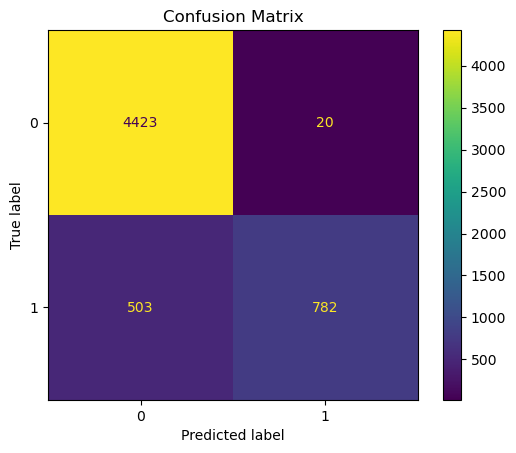

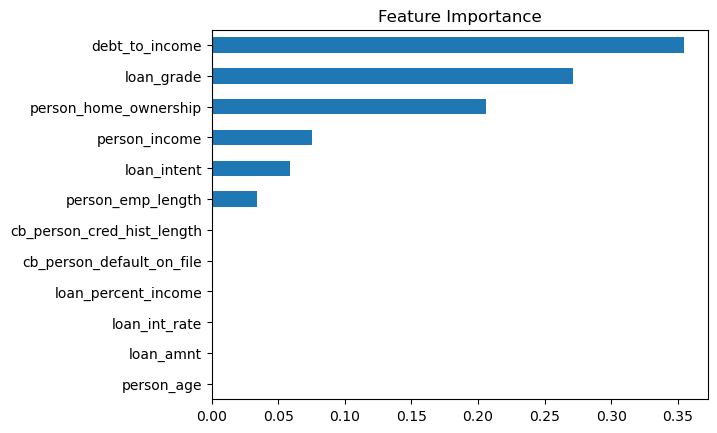

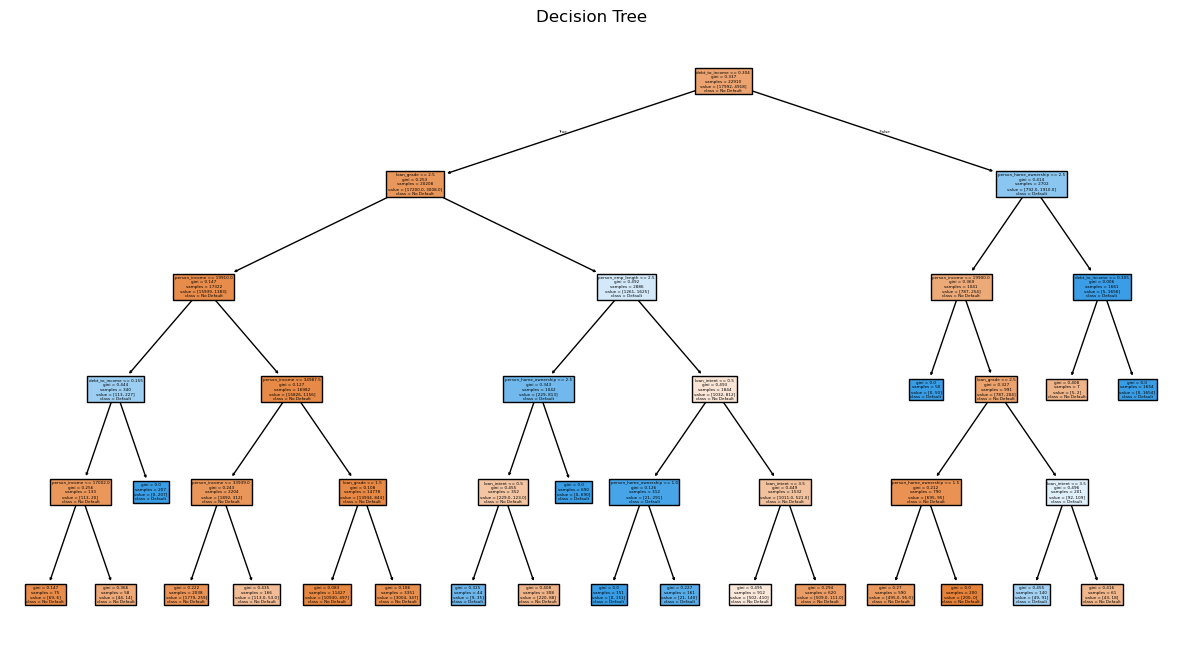

In [14]:
df["debt_to_income"] = df["loan_amnt"] / df["person_income"]
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)


model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n=== Model Performance ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

plt.figure(figsize=(15,8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Default", "Default"],
    filled=True
)
plt.title("Decision Tree")
plt.show()